In [23]:
import numpy as np
import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [24]:
df_train = pd.read_csv('train.csv')
train_length = len(df_train)
df_test = pd.read_csv('test.csv')
df_train.rename(columns = {'Personality (Class label)':'Personality'}, inplace = True) 
df_test.rename(columns = {'Personality (class label)':'Personality'}, inplace = True) 
df = pd.concat([df_train, df_test])
df.head()

,Gender,Age,openness,neuroticism,conscientiousness,agreeableness,extraversion,Personality
0,Male,17,7,4,7,3,2,extraverted
1,Male,19,4,5,4,6,6,serious
2,Female,18,7,6,4,5,5,dependable
3,Female,22,5,6,7,4,3,extraverted
4,Female,19,7,4,6,5,4,lively


In [25]:
df['Gender'] = df['Gender'].map({'Male': 0,
                                 'Female': 1})

df['Personality'] = df['Personality'].map({'dependable': 0,
                                           'extraverted': 1,
                                           'lively': 2,
                                           'responsible': 3,
                                           'serious': 4})

In [26]:
df[df.isnull().sum(axis=1) > 0]
# Found one row with all null values

,Gender,Age,openness,neuroticism,conscientiousness,agreeableness,extraversion,Personality
449,NaN,21,2,5,6,1,5,4


In [27]:
df.groupby(by=['Personality', 'Age']).mean().loc[4]

,Gender,openness,neuroticism,conscientiousness,agreeableness,extraversion
Age,,,,,,
17,0.375000,4.916667,4.208333,5.041667,4.291667,5.375000
18,0.531250,5.000000,4.656250,5.109375,4.968750,4.843750
19,0.506024,4.710843,4.253012,4.433735,5.228916,5.156627
20,0.250000,4.975000,4.225000,5.200000,4.925000,4.825000
21,0.406250,4.575758,4.424242,5.030303,5.030303,5.030303
22,0.476190,5.142857,4.190476,4.619048,5.095238,4.476190
23,0.133333,4.466667,4.133333,4.933333,5.000000,5.000000
24,0.400000,4.866667,4.466667,5.133333,3.933333,5.666667
25,0.500000,5.125000,3.875000,5.375000,4.625000,5.250000


In [28]:
# as the mean value is closer to 0  we can impute missing value with 0
df.at[449, 'Gender'] = 0

<AxesSubplot:>

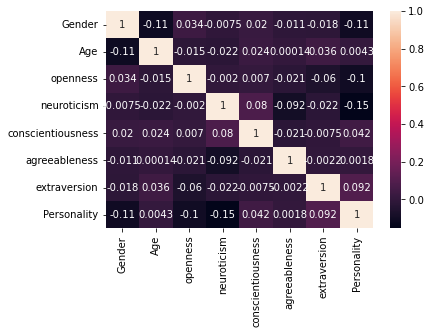

In [29]:
# Find correlation coefficient among the attributes [ heatmap ]
sns.heatmap(df.corr(), annot=True)
# We observe that there are no strong relationships amongs the features

In [30]:
# Check if data are skewed or not which helps to understand where most information is lying & analyze outliers in given data
df.skew()
# we observe that 'agreeableness and openness' has skew value less than -0.5 hence we need to unskew them using square root transformation.

Gender              -0.093991
Age                  0.471614
openness            -0.638642
neuroticism         -0.412167
conscientiousness   -0.412381
agreeableness       -0.552094
extraversion        -0.359830
Personality         -0.140035
dtype: float64

In [31]:
df['openness'] = np.sqrt(max(df['openness']+1) - df['openness'])
df['agreeableness'] = np.sqrt(max(df['agreeableness']+1) - df['agreeableness'])
df.skew()

Gender              -0.093991
Age                  0.471614
openness             0.234889
neuroticism         -0.412167
conscientiousness   -0.412381
agreeableness        0.107320
extraversion        -0.359830
Personality         -0.140035
dtype: float64

In [32]:
df_train = df[:train_length]
df_test = df[train_length:]
Y, X = df_train.values[:,-1], df_train.values[:,:-1]
Y_test, X_test = df_test.values[:,-1], df_test.values[:,:-1]
X = RobustScaler().fit_transform(X)
X_test = RobustScaler().fit_transform(X_test)

In [33]:
df_train['Personality'].value_counts() / len(df_train)

4    0.227080
1    0.211566
0    0.194640
2    0.188999
3    0.177715
Name: Personality, dtype: float64

In [34]:
df_test['Personality'].value_counts() / len(df_test)
# Hence we observe that the results contradict the assumption. Also we observe that both test and train datasets are
# imbalanced. But test data set is even more imbalance as personality 4 is overpowering rest.

4    0.485714
1    0.244444
3    0.126984
2    0.076190
0    0.066667
Name: Personality, dtype: float64

In [35]:
param_grids = {}
models = []

logistic = LogisticRegression()
models.append(logistic)
param_grids[logistic] = {'C':np.arange(0.01, 1, 0.01)}

svc = SVC()
models.append(svc)
param_grids[svc] = {'kernel':['poly','rbf'],
                    'C':np.arange(0.01, 1, 0.01)}

adaboost = AdaBoostClassifier()
models.append(adaboost)
param_grids[adaboost] = {'n_estimators':np.arange(10, 101, 10)}

knn = KNeighborsClassifier()
models.append(knn)
param_grids[knn] = {'n_neighbors':np.arange(2,11,1),
                    'weights':['uniform', 'distance'],
                    'p':np.arange(1,4,1)}

In [36]:
def choose_hyperparameters(models, param_grids, X_train, Y_train):
    cv_models = {}
    scores = {}
    cv_with_scores = {}
    for model in models:
        label = str(type(model)).split('.')[-1].split("'")[0]
        gs = GridSearchCV(model, param_grid=param_grids[model])
        gs.fit(X_train, Y_train)
        cv_models[label] = gs
        scores[label] = gs.best_score_
        cv_with_scores[gs] = gs.best_score_
    return cv_models, scores, cv_with_scores

cv_models, scores, cv_with_scores = choose_hyperparameters(models, param_grids, X, Y)
scores

{'LogisticRegression': 0.23975626810508438,
 'SVC': 0.263779842173609,
 'AdaBoostClassifier': 0.2820497452801918,
 'KNeighborsClassifier': 0.27229048047148136}